In [1]:
from CASP16_NA_assessment import *
# global (capatalized variables) are defined in there

In [2]:
# read hybrid scores
rna_hybrid_results_f = '../raw_scores/RNA_hybrid_results_table.csv'
rnp_defintions_f = '../raw_scores/RNP/casp16_domain_score_rck.csv' 

df_hybrid = pd.read_csv(rna_hybrid_results_f,
                 delim_whitespace=True,
                 usecols=range(21),
                na_values=['-'],
                index_col=False)

col_rename = {'#Model':'model','Gr.Code':'gr_code',
'RMSD':'global_rmsd','lDDT':'lddt',  
 'TMscore':'tm_score','GDT_TS':'gdt_ts',  
'MDL.Clash':'clashes_number','TMalign':'TM_align'}
df_hybrid.rename(columns=col_rename,inplace=True)
df_hybrid['target'] = df_hybrid.model.apply(lambda x: x.split('TS')[0])
df_hybrid = df_hybrid.astype({z:float for z in MULTIMER_METRICS.keys()})
df_hybrid['gr_code'] = df_hybrid.gr_code.apply(lambda x: x[:-1] if 's' in x else x)
df_hybrid['gr_code_'] = df_hybrid.gr_code.copy()

df_hybrid['gr_code'] = df_hybrid.gr_code.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)

print(df_hybrid.dtypes,len(df_hybrid))
df_hybrid.head()
print(df_hybrid.gr_code.unique())


model              object
gr_code            object
ICS(F1)           float64
Prec.Iface        float64
Recal.Iface       float64
IPS               float64
QSglob            float64
QSbest            float64
lddt              float64
ilDDT             float64
gdt_ts            float64
global_rmsd       float64
tm_score          float64
TM_align          float64
GlobDockQ         float64
BestDockQ         float64
Mol.Size            int64
Stoich.            object
MDL.Conts           int64
REF.Conts           int64
clashes_number    float64
target             object
gr_code_           object
dtype: object 2497
['Bhattacharya - 369' 'CoDock - 262' 'GromihaLab - 272' 'Zheng - 462'
 'MIEnsembles-Server - S 110' '405 - 325' '406 - 159' 'AF3-server - S 304'
 'Vfold - 481' 'OpenComplex_Server - S 450' 'isyslab-hust - 235'
 'CSSB_experimental - 286' 'Diff - 033' 'elofsson - 241' 'NKRNA-s - S 028'
 'KiharaLab - 294' 'LCBio - 189' 'GeneSilico - 338' 'OpenComplex - 167'
 'kiharalab_server - S 267

C:\Users\racha\AppData\Local\Temp\ipykernel_41376\2333260867.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_hybrid = pd.read_csv(rna_hybrid_results_f,


In [3]:
### add in domain definitions
hybrid_addition = pd.read_csv(rnp_defintions_f)
hybrid_addition
len(hybrid_addition)
print(hybrid_addition.columns)
for interface,int_hybrid_addition in hybrid_addition.groupby('interface_type'):
    for method in ['naive_','','log10_']:
        ics = int_hybrid_addition.set_index('model')[f'ics_{method}mean'].to_dict()
        ips = int_hybrid_addition.set_index('model')[f'ips_{method}mean'].to_dict()
        ilddt = int_hybrid_addition.set_index('model')[f'ilddt_{method}mean'].to_dict()
        df_hybrid[f'{interface}_{method}ICS(F1)'] = df_hybrid.model.map(ics)
        df_hybrid[f'{interface}_{method}IPS'] = df_hybrid.model.map(ips)
        df_hybrid[f'{interface}_{method}ilDDT'] = df_hybrid.model.map(ilddt)

df_hybrid.columns
print(df_hybrid[~df_hybrid['NA-containing_ilDDT'].isna()].gr_code.unique())

df_hybrid.to_csv('summary_tables/hybrid_scores.csv')

Index(['interface_type', 'model', 'target', 'ics_naive_mean', 'ics_mean',
       'ics_log10_mean', 'ips_naive_mean', 'ips_mean', 'ips_log10_mean',
       'ilddt_naive_mean', 'ilddt_mean', 'ilddt_log10_mean'],
      dtype='object')
['Bhattacharya - 369' 'CoDock - 262' 'GromihaLab - 272' 'Zheng - 462'
 'MIEnsembles-Server - S 110' '405 - 325' '406 - 159' 'AF3-server - S 304'
 'Vfold - 481' 'OpenComplex_Server - S 450' 'isyslab-hust - 235'
 'CSSB_experimental - 286' 'Diff - 033' 'elofsson - 241' 'NKRNA-s - S 028'
 'KiharaLab - 294' 'LCBio - 189' 'GeneSilico - 338' 'OpenComplex - 167'
 'kiharalab_server - S 267' 'B-LAB - 231' 'GuangzhouRNA-human - 183'
 'GuangzhouRNA-meta - 417' 'GuangzhouRNA_AI - 317' 'RNApolis - 063'
 'OmniFold - 400' 'falcon2 - S 208' 'dMNAfold - 143' 'dNAfold - 448'
 'Huang-HUST - 091' 'RNA_Dojo - 006' '225' '044' 'Pcons - S 471' '489'
 '204' '323' '014' '022' 'Zheng-Multimer - S 147' 'MULTICOM - 051'
 'MULTICOM_human - 345' '274' 'MULTICOM_LLM - S 319'
 'MULTICOM_GATE

<Axes: xlabel='ilDDT', ylabel='all_ilDDT'>

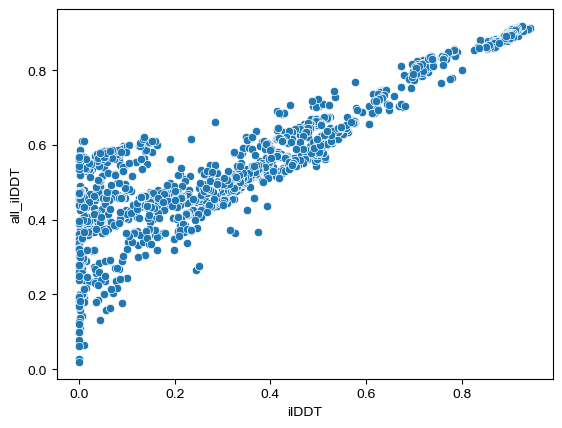

In [4]:
sns.scatterplot(df_hybrid,x='ilDDT',y='all_ilDDT')

In [5]:
hybrid_addition['interface_type'].unique()

array(['all', 'NA-NA', 'NA-protein', 'protein-protein', 'NA-containing'],
      dtype=object)

In [6]:
# hetereo to add to nucleic-acid nucleic-acid scores but not rankings
df_hybrid[~df_hybrid['NA-NA_ilDDT'].isna()].target.unique()

array(['M0287', 'M1212', 'M1216', 'M1221', 'M1224', 'M1228v1', 'M1228v2',
       'M1239v1', 'M1239v2', 'M1268', 'M1287'], dtype=object)

In [7]:
df_hybrid

,model,gr_code,ICS(F1),Prec.Iface,Recal.Iface,IPS,QSglob,QSbest,lddt,ilDDT,...,all_log10_ilDDT,protein-protein_naive_ICS(F1),protein-protein_naive_IPS,protein-protein_naive_ilDDT,protein-protein_ICS(F1),protein-protein_IPS,protein-protein_ilDDT,protein-protein_log10_ICS(F1),protein-protein_log10_IPS,protein-protein_log10_ilDDT
0,M0276TS369_1,Bhattacharya - 369,0.847,0.900,0.800,0.933,0.786,0.804,0.863,0.413,...,0.639897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M0276TS262_4,CoDock - 262,0.805,0.833,0.778,0.903,0.515,0.766,0.861,0.440,...,0.706966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M0276TS272_1,GromihaLab - 272,0.790,0.889,0.711,0.812,0.352,0.848,0.872,0.489,...,0.703931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M0276TS462_2,Zheng - 462,0.635,0.675,0.600,0.781,0.816,0.829,0.864,0.425,...,0.683552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M0276TS110_2,MIEnsembles-Server - S 110,0.635,0.675,0.600,0.781,0.816,0.829,0.864,0.425,...,0.683552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2492,M1297TS241_2,elofsson - 241,0.308,0.284,0.338,0.470,0.093,0.264,0.517,0.175,...,0.427590,0.292889,0.269944,0.409839,0.434272,0.416673,0.470813,0.391177,0.365137,0.451225
2493,M1297TS304_3,AF3-server - S 304,0.277,0.257,0.301,0.463,0.089,0.250,0.490,0.151,...,0.413402,0.326944,0.309278,0.416554,0.446858,0.442142,0.476358,0.399815,0.388852,0.456206
2494,M1297TS241_4,elofsson - 241,0.275,0.255,0.297,0.458,0.095,0.248,0.509,0.142,...,0.410551,0.282667,0.273167,0.402953,0.429706,0.419699,0.465392,0.372880,0.361167,0.443042
2495,M1297TS304_4,AF3-server - S 304,0.275,0.255,0.297,0.458,0.095,0.248,0.509,0.142,...,0.410551,0.282667,0.273167,0.402953,0.429706,0.419699,0.465392,0.372880,0.361167,0.443042


In [8]:
df_hybrid[df_hybrid.target=='M1224'].sort_values('NA-NA_ICS(F1)',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
796,M1224,M1224TS262_4,CoDock - 262,0.581,0.520409
797,M1224,M1224TS262_2,CoDock - 262,0.581,0.520136
803,M1224,M1224TS286_4,CSSB_experimental - 286,0.575,0.600333
804,M1224,M1224TS272_1,GromihaLab - 272,0.523,0.524470
818,M1224,M1224TS338_2,GeneSilico - 338,0.522,0.543515
...,...,...,...,...,...
899,M1224,M1224TS014_4,014,NaN,NaN
900,M1224,M1224TS014_3,014,NaN,NaN
901,M1224,M1224TS014_2,014,NaN,NaN
904,M1224,M1224TS014_1,014,NaN,NaN


In [9]:
df_hybrid[df_hybrid.target=='M1224'].sort_values('NA-NA_ilDDT',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
803,M1224,M1224TS286_4,CSSB_experimental - 286,0.575,0.600333
799,M1224,M1224TS481_2,Vfold - 481,0.435,0.579833
800,M1224,M1224TS286_3,CSSB_experimental - 286,0.438,0.579000
818,M1224,M1224TS338_2,GeneSilico - 338,0.522,0.543515
834,M1224,M1224TS338_5,GeneSilico - 338,0.410,0.537803
...,...,...,...,...,...
899,M1224,M1224TS014_4,014,NaN,NaN
900,M1224,M1224TS014_3,014,NaN,NaN
901,M1224,M1224TS014_2,014,NaN,NaN
904,M1224,M1224TS014_1,014,NaN,NaN


In [10]:
df_hybrid[df_hybrid.target=='M1221'].sort_values('NA-NA_ICS(F1)',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
704,M1221,M1221TS262_4,CoDock - 262,0.562,0.478738
702,M1221,M1221TS262_2,CoDock - 262,0.562,0.479262
703,M1221,M1221TS262_5,CoDock - 262,0.547,0.458311
705,M1221,M1221TS262_1,CoDock - 262,0.547,0.457508
706,M1221,M1221TS262_3,CoDock - 262,0.547,0.457557
...,...,...,...,...,...
785,M1221,M1221TS014_3,014,NaN,NaN
787,M1221,M1221TS014_1,014,NaN,NaN
790,M1221,M1221TS014_4,014,NaN,NaN
793,M1221,M1221TS014_5,014,NaN,NaN


In [11]:
df_hybrid[df_hybrid.target=='M1221'].sort_values('NA-NA_ilDDT',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
698,M1221,M1221TS481_4,Vfold - 481,0.396,0.534262
699,M1221,M1221TS481_2,Vfold - 481,0.396,0.534262
697,M1221,M1221TS481_5,Vfold - 481,0.396,0.534180
720,M1221,M1221TS481_3,Vfold - 481,0.396,0.525656
695,M1221,M1221TS481_1,Vfold - 481,0.540,0.507492
...,...,...,...,...,...
785,M1221,M1221TS014_3,014,NaN,NaN
787,M1221,M1221TS014_1,014,NaN,NaN
790,M1221,M1221TS014_4,014,NaN,NaN
793,M1221,M1221TS014_5,014,NaN,NaN


In [12]:
df_hybrid[df_hybrid.target=='M1212'].sort_values('NA-NA_ICS(F1)',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
519,M1212,M1212TS338_2,GeneSilico - 338,0.678391,0.292152
523,M1212,M1212TS338_4,GeneSilico - 338,0.678391,0.276065
525,M1212,M1212TS338_3,GeneSilico - 338,0.678391,0.292870
520,M1212,M1212TS338_1,GeneSilico - 338,0.678391,0.292174
521,M1212,M1212TS262_1,CoDock - 262,0.675261,0.728652
...,...,...,...,...,...
603,M1212,M1212TS014_5,014,NaN,NaN
606,M1212,M1212TS014_2,014,NaN,NaN
610,M1212,M1212TS014_1,014,NaN,NaN
611,M1212,M1212TS014_4,014,NaN,NaN


In [13]:
df_hybrid[df_hybrid.target=='M1212'].sort_values('NA-protein_ICS(F1)',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT','NA-protein_ICS(F1)']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT,NA-protein_ICS(F1)
519,M1212,M1212TS338_2,GeneSilico - 338,0.678391,0.292152,0.544975
520,M1212,M1212TS338_1,GeneSilico - 338,0.678391,0.292174,0.543914
523,M1212,M1212TS338_4,GeneSilico - 338,0.678391,0.276065,0.517370
522,M1212,M1212TS338_5,GeneSilico - 338,0.670478,0.293609,0.516309
525,M1212,M1212TS338_3,GeneSilico - 338,0.678391,0.292870,0.514185
...,...,...,...,...,...,...
603,M1212,M1212TS014_5,014,NaN,NaN,NaN
606,M1212,M1212TS014_2,014,NaN,NaN,NaN
610,M1212,M1212TS014_1,014,NaN,NaN,NaN
611,M1212,M1212TS014_4,014,NaN,NaN,NaN


In [14]:
df_hybrid[df_hybrid.target=='M1276'].sort_values('NA-protein_ICS(F1)',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT','NA-protein_ICS(F1)']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT,NA-protein_ICS(F1)
1625,M1276,M1276TS369_1,Bhattacharya - 369,NaN,NaN,0.828
1626,M1276,M1276TS028_5,NKRNA-s - S 028,NaN,NaN,0.810
1627,M1276,M1276TS110_5,MIEnsembles-Server - S 110,NaN,NaN,0.750
1628,M1276,M1276TS051_5,MULTICOM - 051,NaN,NaN,0.644
1629,M1276,M1276TS345_5,MULTICOM_human - 345,NaN,NaN,0.644
...,...,...,...,...,...,...
1753,M1276,M1276TS014_1,014,NaN,NaN,NaN
1754,M1276,M1276TS331_3,MULTICOM_AI - S 331,NaN,NaN,NaN
1757,M1276,M1276TS319_2,MULTICOM_LLM - S 319,NaN,NaN,NaN
1758,M1276,M1276TS425_1,MULTICOM_GATE - S 425,NaN,NaN,NaN


In [15]:
df_hybrid[df_hybrid.target=='M1276'].sort_values('NA-protein_ilDDT',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT','NA-protein_ICS(F1)']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT,NA-protein_ICS(F1)
1626,M1276,M1276TS028_5,NKRNA-s - S 028,NaN,NaN,0.810
1634,M1276,M1276TS028_4,NKRNA-s - S 028,NaN,NaN,0.605
1630,M1276,M1276TS241_3,elofsson - 241,NaN,NaN,0.644
1631,M1276,M1276TS304_1,AF3-server - S 304,NaN,NaN,0.644
1627,M1276,M1276TS110_5,MIEnsembles-Server - S 110,NaN,NaN,0.750
...,...,...,...,...,...,...
1753,M1276,M1276TS014_1,014,NaN,NaN,NaN
1754,M1276,M1276TS331_3,MULTICOM_AI - S 331,NaN,NaN,NaN
1757,M1276,M1276TS319_2,MULTICOM_LLM - S 319,NaN,NaN,NaN
1758,M1276,M1276TS425_1,MULTICOM_GATE - S 425,NaN,NaN,NaN


In [16]:
df_hybrid[df_hybrid.target=='M1221'].sort_values('NA-NA_ilDDT',ascending=False)[['target','model','gr_code','NA-NA_ICS(F1)','NA-NA_ilDDT']]

,target,model,gr_code,NA-NA_ICS(F1),NA-NA_ilDDT
698,M1221,M1221TS481_4,Vfold - 481,0.396,0.534262
699,M1221,M1221TS481_2,Vfold - 481,0.396,0.534262
697,M1221,M1221TS481_5,Vfold - 481,0.396,0.534180
720,M1221,M1221TS481_3,Vfold - 481,0.396,0.525656
695,M1221,M1221TS481_1,Vfold - 481,0.540,0.507492
...,...,...,...,...,...
785,M1221,M1221TS014_3,014,NaN,NaN
787,M1221,M1221TS014_1,014,NaN,NaN
790,M1221,M1221TS014_4,014,NaN,NaN
793,M1221,M1221TS014_5,014,NaN,NaN


In [17]:
# reduce to one (best) score per group per target
columns = ['target', 'gr_code']
best1_df_hybrid = reduce_df(df_hybrid, score_to_choice_best=None,
               static_columns=columns, metric_dict=HYBRID_METRICS,
                            participipation_cutoff=PARTICIPATION_RATE,participation_score='NA-containing_ilDDT',
              participation_targets=HYBRID_TARGETS)

# TODO M0276', 'M0287', 'M1209',

# on the one model per group per target, calculate Z-scores for each metric
temp_dfs = []

for target in HYBRID_TARGETS:
    #print(target)
    target_df = best1_df_hybrid[best1_df_hybrid.target==target].copy()
    #print(target_df.columns)
    for metric in HYBRID_METRICS.keys():
        #print(target_df[metric])
        #print(metric)
        if ('inf' in metric and target in ['D1273','R1286']) or (metric == 'clashscore' and target in ['R1286']):
            target_df["Z_"+metric] = 0
        else:
            target_df["Z_"+metric] = get_zscore(target_df[metric].to_numpy(copy=True),
                                            negative=(HYBRID_METRICS[metric]=="min"),
                                            tolerance_threshold=-2,
                                           penalty_threshold=None)
    temp_dfs.append(target_df)
best1_df_hybrid = pd.concat(temp_dfs) 

# get weighted Zs
for name,score_wieghts in HYBRID_SCORES.items():
    best1_df_hybrid[name] = get_weighted_sum_z(best1_df_hybrid.copy(), score_wieghts, "Z_")

combing the following columns: ['model', 'Mol.Size', 'Stoich.', 'MDL.Conts', 'REF.Conts', 'gr_code_']
gr_code
014                           0.1250
015                           0.0000
022                           0.0625
044                           0.1250
075                           0.0000
163                           0.0000
164                           0.0000
204                           0.2500
225                           0.1250
274                           0.0625
284                           0.0000
301                           0.0000
323                           0.0625
375                           0.0000
405 - 325                     0.5625
406 - 159                     0.6250
475                           0.0000
489                           0.3125
494                           0.0000
AF3-server - S 304            0.9375
B-LAB - 231                   0.8125
Bhattacharya - 369            0.7500
CSSB_experimental - 286       1.0000
CoDock - 262                  1.0000
Di

C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:793: RuntimeWarning: Mean of empty slice
  u = np.nanmean(arr)
C:\Users\racha\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = n

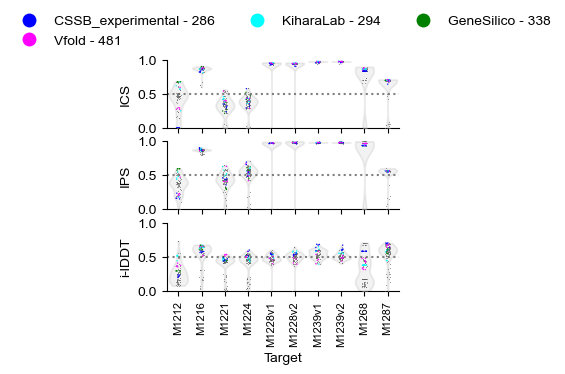

In [18]:

int_type = 'NA-NA' # all NA-protein protein-protein
metrics_to_plot = [f'{int_type}_ICS(F1)',f'{int_type}_IPS',f'{int_type}_ilDDT'] #MULTIMER_METRICS.keys()
labels = {f'{int_type}_ilDDT':'i-lDDT',f'{int_type}_ICS(F1)':'ICS',f'{int_type}_IPS':'IPS'}

target_order = [x for x in df_hybrid.target.unique() if 'M1' in x] # only round 1
fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,1*len(metrics_to_plot)),sharex=True)
for i,metric in enumerate(metrics_to_plot):

    # don't plot the ones without na-na interface
    filtered_data = df_hybrid[df_hybrid[metric].notna()]
    pass_targets = filtered_data.target.unique()
    new_target_order = []
    for targ in target_order:
        if targ in pass_targets:
            new_target_order.append(targ)

    sns.violinplot(filtered_data,x='target',y=metric,color='grey',
                   inner=None,ax=axes[i],alpha=0.1,density_norm='width',
                   cut=0,order=new_target_order)
    g=sns.stripplot(filtered_data[~filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=new_target_order)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(filtered_data[filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=1, hue='gr_code',palette=GROUP_HIGHLIGHTS,ax=axes[i],
                    order=new_target_order,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_ylabel(labels[metric])
    g.set_xticks(g.get_xticks())
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90,size=8)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,markerscale=10)
t=axes[-1].set_xticklabels(new_target_order,rotation=90)
plt.savefig("figure_subpanels/hybrid_na-na_interface_scores.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/hybrid_na-na_interface_scores.png",dpi=400, bbox_inches='tight', transparent=True)

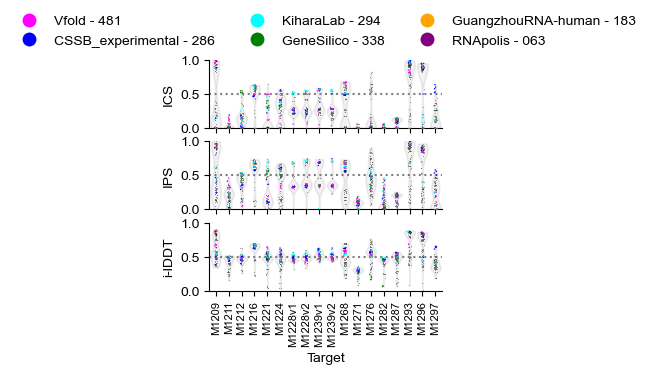

In [19]:

int_type = 'NA-protein' # all NA-protein protein-protein
metrics_to_plot = [f'{int_type}_ICS(F1)',f'{int_type}_IPS',f'{int_type}_ilDDT'] #MULTIMER_METRICS.keys()
labels = {f'{int_type}_ilDDT':'i-lDDT',f'{int_type}_ICS(F1)':'ICS',f'{int_type}_IPS':'IPS'}

target_order = [x for x in df_hybrid.target.unique() if 'M1' in x] # only round 1
fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,1*len(metrics_to_plot)),sharex=True)
for i,metric in enumerate(metrics_to_plot):

    # don't plot the ones without na-na interface
    filtered_data = df_hybrid[df_hybrid[metric].notna()]
    pass_targets = filtered_data.target.unique()
    new_target_order = []
    for targ in target_order:
        if targ in pass_targets:
            new_target_order.append(targ)

    sns.violinplot(filtered_data,x='target',y=metric,color='grey',
                   inner=None,ax=axes[i],alpha=0.1,density_norm='width',
                   cut=0,order=new_target_order)
    g=sns.stripplot(filtered_data[~filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=new_target_order)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(filtered_data[filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=1, hue='gr_code',palette=GROUP_HIGHLIGHTS,ax=axes[i],
                    order=new_target_order,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_ylabel(labels[metric])
    g.set_xticks(g.get_xticks())
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90,size=8)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,markerscale=10)
t=axes[-1].set_xticklabels(new_target_order,rotation=90)
plt.savefig("figure_subpanels/hybrid_na-protein_interface_scores.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/hybrid_na-protein_interface_scores.png",dpi=400, bbox_inches='tight', transparent=True)

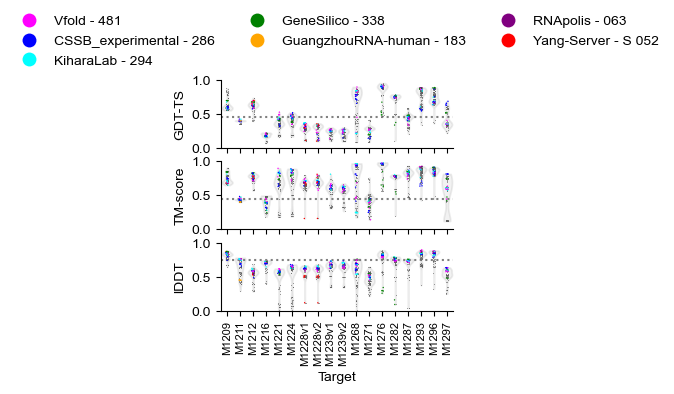

In [20]:

metrics_to_plot = ['gdt_ts','tm_score','lddt'] #MULTIMER_METRICS.keys()
labels = {'lddt':'lDDT','tm_score':'TM-score','gdt_ts':'GDT-TS'}


target_order = [x for x in df_hybrid.target.unique() if 'M1' in x] # only round 1
fig,axes=plt.subplots(len(metrics_to_plot),1,figsize=(3,1*len(metrics_to_plot)),sharex=True)
for i,metric in enumerate(metrics_to_plot):

    # don't plot the ones without na-na interface
    filtered_data = df_hybrid[df_hybrid[metric].notna()]
    pass_targets = filtered_data.target.unique()
    new_target_order = []
    for targ in target_order:
        if targ in pass_targets:
            new_target_order.append(targ)

    sns.violinplot(filtered_data,x='target',y=metric,color='grey',
                   inner=None,ax=axes[i],alpha=0.1,density_norm='width',
                   cut=0,order=new_target_order)
    g=sns.stripplot(filtered_data[~filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=0.5, color='grey',ax=axes[i],order=new_target_order)
    # swarmplot
    #for g,c in group_highlights.items():
    g=sns.stripplot(filtered_data[filtered_data.gr_code.isin(GROUP_HIGHLIGHTS.keys())],
                    x='target',y=metric,size=1, hue='gr_code',palette=GROUP_HIGHLIGHTS,ax=axes[i],
                    order=new_target_order,legend=(i==0))

    if metric in METRIC_RANGES:
        g.set_ylim(METRIC_RANGES[metric][0],METRIC_RANGES[metric][1])
    else:
        g.set_ylim(0,1)
    xmin,xmax = g.get_xlim()
    if metric in METRIC_PASS_SCORE:
        g.hlines(METRIC_PASS_SCORE[metric],xmin,xmax,"grey",":")
    g.set_xlim(xmin,xmax)
    g.set_ylabel(labels[metric])
    g.set_xticks(g.get_xticks())
    g.set_xlabel('Target')
    g.set_xticklabels(labels=g.get_xticklabels(),rotation = 90,size=8)
    g.spines[['right', 'top']].set_visible(False)
sns.move_legend(axes[0], "lower center", bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,markerscale=10)
t=axes[-1].set_xticklabels(new_target_order,rotation=90)
plt.savefig("figure_subpanels/hybrid_fold_scores.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig("figure_subpanels/hybrid_fold_scores.png",dpi=400, bbox_inches='tight', transparent=True)

## compare sem to boot

In [34]:
score,boot_df = get_group_score_bootstrap(best1_df_hybrid,score='Z_0.3_0.7_NA',n_bootstraps=1000)
score,boot_df_3000 = get_group_score_bootstrap(best1_df_hybrid,score='Z_0.3_0.7_NA',n_bootstraps=3000)

100%|███████████████████████████████| 3000/3000 [06:34<00:00,  7.61it/s]


In [59]:
ok_groups = df_hybrid[~df_hybrid['NA-containing_ilDDT'].isna()].gr_code.unique()
ok_groups = [g for g in ok_groups if g in score.index]
part_issues = ['015', '022', '044', '075', '163', '164', '204', '225', '274', '284',
       '301', '323', '375', '405 - 325', '475', '489', '494',
       'GuangzhouRNA-human - 183', 'GuangzhouRNA-meta - 417',
       'GuangzhouRNA_AI - 317', 'LCBio - 189', 'MULTICOM - 051',
       'MULTICOM_AI - 331', 'MULTICOM_GATE - 425', 'MULTICOM_LLM - 319',
       'MULTICOM_human - 345', 'OmniFold - 400', 'Pcons - 471',
       'RNA_Dojo - 006', 'RNApolis - 063', 'Yang-Multimer - 456',
       'Yang-Server - 052', 'Zheng-Multimer - 147', 'dNAfold - 448',
       'isyslab-hust - 235']
ok_groups = [g for g in ok_groups if g not in part_issues]

sem = best1_df_hybrid.groupby('gr_code')['Z_0.3_0.7_NA'].sem()
boot_df = boot_df.loc[ok_groups]
boot_df_3000 = boot_df_3000.loc[ok_groups]
sem = sem.loc[ok_groups]

In [60]:
data.quantile(0.4)

4.7374146475895715

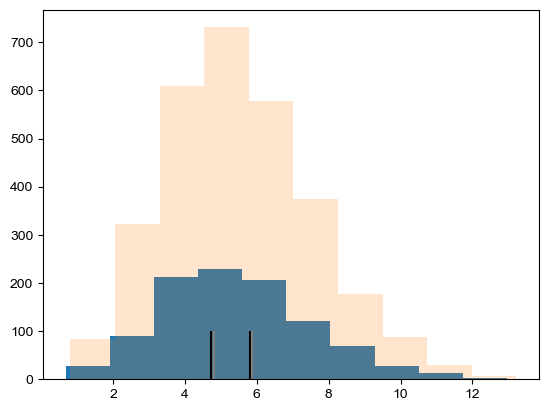

In [61]:
data = boot_df.loc['CoDock - 262'][list(range(1000))]
data3 = boot_df_3000.loc['CoDock - 262'][list(range(3000))]

plt.hist(data)
plt.hist(data3,alpha=0.2)

quant = 0.6
plt.vlines(data.quantile(quant),0,100,'black')
plt.vlines(data.quantile(1-quant),0,100,'black')
plt.vlines(data3.quantile(quant),0,100,'grey')
plt.vlines(data3.quantile(1-quant),0,100,'grey')

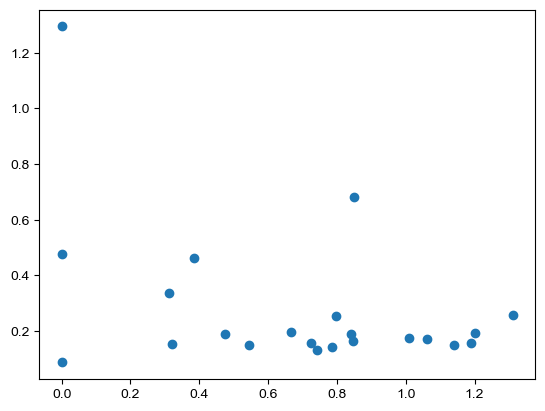

In [62]:
plt.scatter(boot_df[list(range(1000))].quantile(quant,axis=1)-boot_df[list(range(1000))].quantile(1-quant,axis=1),sem)

In [64]:
sem

gr_code
Bhattacharya - 369          0.148499
CoDock - 262                0.172595
GromihaLab - 272            0.681468
Zheng - 462                 0.193884
MIEnsembles-Server - 110    0.165570
406 - 159                   0.190990
AF3-server - 304            0.196839
Vfold - 481                 0.156878
OpenComplex_Server - 450    0.463639
CSSB_experimental - 286     0.259027
Diff - 033                  0.189138
elofsson - 241              0.130652
NKRNA-s - 028               0.158334
KiharaLab - 294             0.150636
GeneSilico - 338            0.253806
OpenComplex - 167           0.335194
kiharalab_server - 267      1.294530
B-LAB - 231                 0.141891
falcon2 - 208               0.153338
dMNAfold - 143              0.476424
Huang-HUST - 091            0.175726
014                         0.086867
Name: Z_0.3_0.7_NA, dtype: float64

In [63]:
boot_df

,0,1,2,3,4,5,6,7,8,9,...,995,996,997,998,999,mean_Z_0.3_0.7_NA,sem_Z_0.3_0.7_NA,std_Z_0.3_0.7_NA,q2.5_Z_0.3_0.7_NA,q97.5_Z_0.3_0.7_NA
gr_code,,,,,,,,,,,,,,,,,,,,,
Bhattacharya - 369,1.954048,3.205313,0.449309,2.428149,1.608919,2.798978,1.568663,3.363969,3.504081,3.206504,...,1.246785,1.637032,0.724783,1.676097,2.350992,2.113567,0.034630,1.095082,0.449309,4.589017
CoDock - 262,5.266675,7.204210,1.687806,4.351649,4.465539,4.465618,4.748658,5.691920,5.243037,2.534738,...,7.336745,3.146953,4.278417,8.555400,4.368870,5.446964,0.065038,2.056687,1.845355,9.924803
GromihaLab - 272,2.671624,1.734116,2.372038,0.799374,3.645277,2.819524,2.717126,4.377938,3.380702,6.003494,...,5.457614,4.571520,5.470362,0.462785,5.006719,3.340692,0.051109,1.616213,0.570536,6.929395
Zheng - 462,7.160206,8.627908,12.681664,5.810381,6.732645,7.128604,9.876442,7.727198,7.471046,7.619212,...,7.947408,5.499740,8.476324,5.472014,8.597527,7.639619,0.067379,2.130723,3.783925,11.943161
MIEnsembles-Server - 110,8.186291,7.435776,9.065234,5.385010,7.609998,8.983708,6.500324,6.335151,7.096506,9.574912,...,6.645139,7.820869,7.686135,5.992808,7.073597,7.028206,0.054718,1.730322,3.876575,10.382997
406 - 159,1.978553,1.662499,2.801351,0.556086,1.888367,2.155079,1.779066,1.239101,2.121857,3.147663,...,3.367244,3.001066,2.898052,0.925812,1.239101,1.951533,0.029936,0.946670,0.369726,4.063887
AF3-server - 304,2.818743,4.298941,2.759463,3.297190,1.232671,5.789048,2.777693,5.593583,5.387660,5.106185,...,3.184892,2.473452,3.745164,4.344410,1.011261,3.592832,0.044198,1.397648,1.186082,6.504496
Vfold - 481,4.530801,2.822166,5.791712,10.236093,11.198349,8.489171,5.190166,5.680783,6.978517,5.185328,...,9.776925,7.579410,7.633566,8.425561,6.675098,7.641486,0.071568,2.263169,3.649715,12.304551
OpenComplex_Server - 450,2.198021,2.934141,2.533576,0.380086,1.505034,1.107752,0.401446,1.487265,0.741991,1.077672,...,0.711190,2.215217,0.410600,2.184703,2.590153,1.435700,0.027306,0.863488,0.026636,3.355569


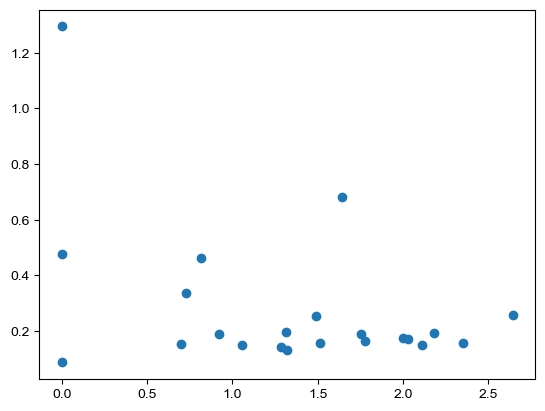

In [17]:
plt.scatter(boot_df['std_Z_0.3_0.7_NA'],sem)

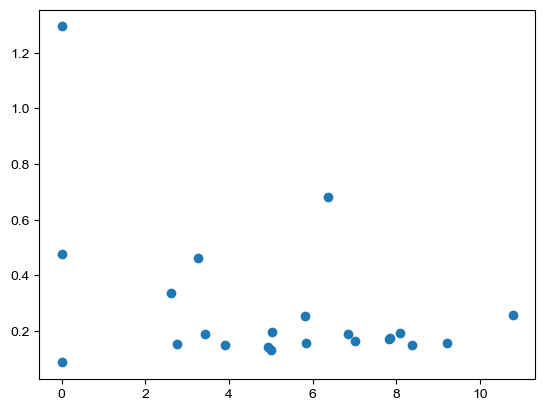

In [18]:
plt.scatter(boot_df['q97.5_Z_0.3_0.7_NA']-boot_df['q2.5_Z_0.3_0.7_NA'],sem)

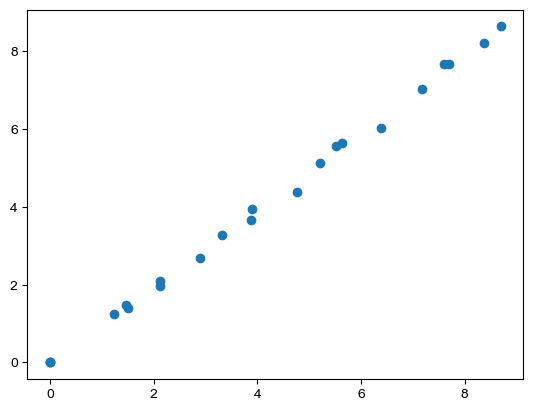

In [13]:
plt.scatter(score,bootmean)

(array([3., 1., 5., 4., 0., 0., 0., 2., 2., 2.]),
 array([-0.01759957, -0.00780874,  0.0019821 ,  0.01177293,  0.02156377,
         0.0313546 ,  0.04114544,  0.05093628,  0.06072711,  0.07051795,
         0.08030878]),
 <BarContainer object of 10 artists>)

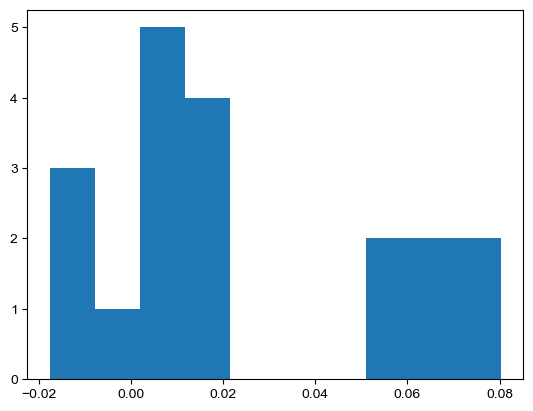

In [16]:
plt.hist((score.iloc[:, 0]-bootmean)/score.iloc[:, 0])

(array([3., 0., 2., 2., 2., 5., 2., 2., 3., 1.]),
 array([0.        , 0.00826913, 0.01653825, 0.02480738, 0.0330765 ,
        0.04134563, 0.04961476, 0.05788388, 0.06615301, 0.07442214,
        0.08269126]),
 <BarContainer object of 10 artists>)

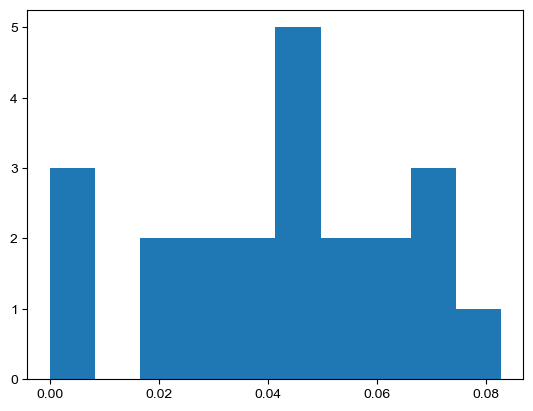

In [17]:
plt.hist(bootstd)

## plot rankings

['Z_lddt', 'Z_tm_score', 'Z_gdt_ts', 'Z_TM_align', 'Z_global_rmsd', 'Z_clashes_number', 'Z_ICS(F1)', 'Z_Prec.Iface', 'Z_Recal.Iface', 'Z_IPS', 'Z_QSglob', 'Z_QSbest', 'Z_ilDDT', 'Z_GlobDockQ', 'Z_BestDockQ', 'Z_NA-protein_naive_IPS', 'Z_NA-protein_IPS', 'Z_NA-protein_log10_IPS', 'Z_NA-NA_naive_IPS', 'Z_NA-NA_IPS', 'Z_NA-NA_log10_IPS', 'Z_protein-protein_naive_IPS', 'Z_protein-protein_IPS', 'Z_protein-protein_log10_IPS', 'Z_all_naive_IPS', 'Z_all_IPS', 'Z_all_log10_IPS', 'Z_NA-containing_naive_IPS', 'Z_NA-containing_IPS', 'Z_NA-containing_log10_IPS', 'Z_NA-protein_naive_ICS(F1)', 'Z_NA-protein_ICS(F1)', 'Z_NA-protein_log10_ICS(F1)', 'Z_NA-NA_naive_ICS(F1)', 'Z_NA-NA_ICS(F1)', 'Z_NA-NA_log10_ICS(F1)', 'Z_protein-protein_naive_ICS(F1)', 'Z_protein-protein_ICS(F1)', 'Z_protein-protein_log10_ICS(F1)', 'Z_all_naive_ICS(F1)', 'Z_all_ICS(F1)', 'Z_all_log10_ICS(F1)', 'Z_NA-containing_naive_ICS(F1)', 'Z_NA-containing_ICS(F1)', 'Z_NA-containing_log10_ICS(F1)', 'Z_NA-protein_naive_ilDDT', 'Z_NA-pr

100%|██████████| 1000/1000 [00:24<00:00, 40.07it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,


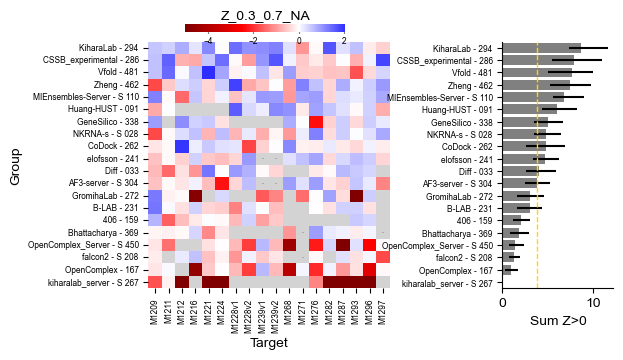

In [21]:
potential_Zs = [x for x in list(best1_df_hybrid.columns) if x[0]=='Z']
print(potential_Zs)
#for Z in potential_Zs:
#Z = 'Z_0.3_0.7'
#plot_heat_map(best1_df_hybrid,Z,savefig=f'figure_subpanels/CASP16_rna_hybrid_{Z}',num_bootstrap=1000)
Z = 'Z_0.3_0.7_NA'
rank,group,ci = plot_heat_map(best1_df_hybrid,Z,savefig=f'figure_subpanels/CASP16_rna_hybrid_{Z}',num_bootstrap=1000,figsize=(6,4),targets_to_choose_best=TARGETS_CHOOSE_BEST,
                             vmin=-5)
# hybrid ranking should only take Na-protien and NA-Na into account

# TODO targets to choose best....

In [22]:
group['lower_bound'] = ci[0]
group['upper_bound'] = ci[1]
group.to_csv('summary_tables/final_Z_NA_hybrid.csv')

100%|██████████| 1000/1000 [00:24<00:00, 41.14it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|██████████| 1000/1000 [00:25<00:00, 39.83it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessment\analysis\CASP16_NA_assessment.py:1247: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all = df_copy.pivot_table(index=group_col, columns=target_col, values=score,
100%|██████████| 1000/1000 [00:25<00:00, 39.39it/s]
C:\Users\racha\OneDrive\Desktop\CASP16_NA\NA_CASP_assessme

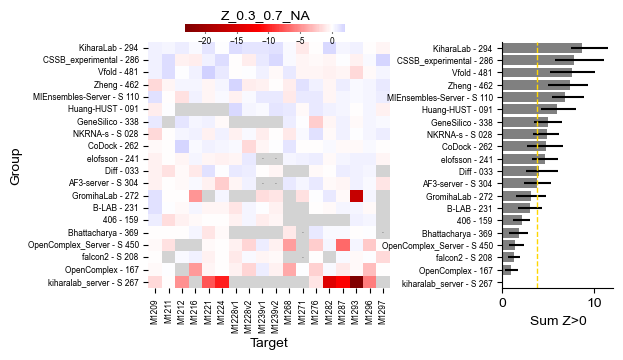

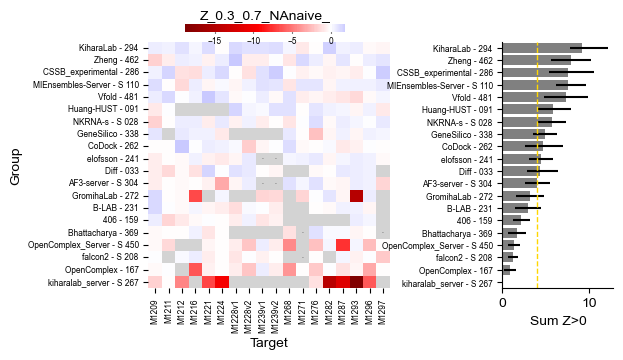

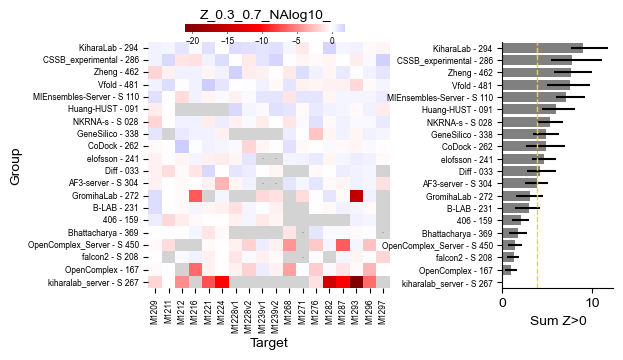

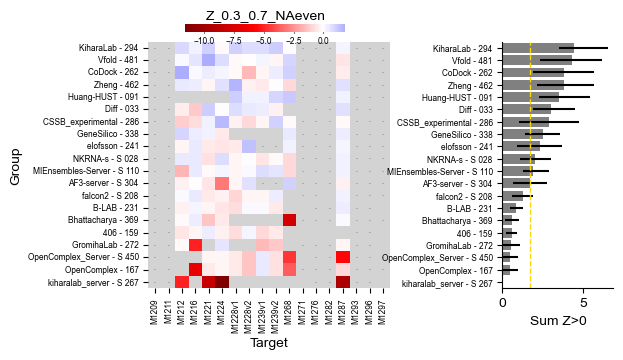

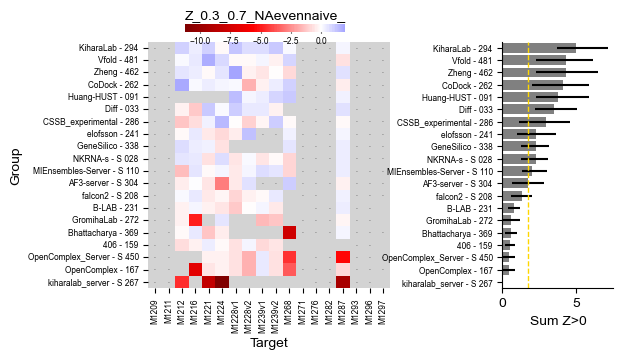

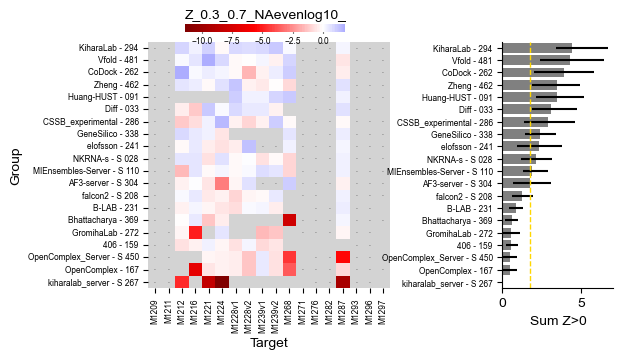

In [23]:
for Z in ['Z_0.3_0.7_NA','Z_0.3_0.7_NAnaive_','Z_0.3_0.7_NAlog10_','Z_0.3_0.7_NAeven','Z_0.3_0.7_NAevennaive_','Z_0.3_0.7_NAevenlog10_']:
    plot_heat_map(best1_df_hybrid,Z,savefig=f'figure_subpanels/CASP16_rna_hybrid_{Z}',num_bootstrap=1000,figsize=(6,4))
